<a href="https://colab.research.google.com/github/241541601038-glitch/JALIZ/blob/main/EX11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving one.jpg to one.jpg


SURF not available (possibly due to patent restrictions). Attempting SIFT.
Using SIFT instead of SURF.


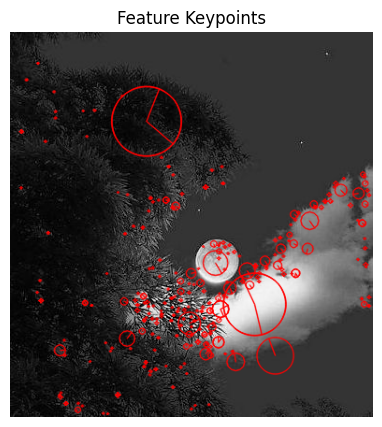

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def surf_feature_detection(image_path):
  image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  if image is None:
    print(f"Error loading image from {image_path}")
    return [], []
  try:
    # Try to create SURF detector
    surf = cv2.xfeatures2d.SURF_create()
  except (AttributeError, cv2.error): # Catch both AttributeError and cv2.error
    print("SURF not available (possibly due to patent restrictions). Attempting SIFT.")
    try:
      # Fallback to SIFT detector
      surf = cv2.SIFT_create()
      print("Using SIFT instead of SURF.")
    except (AttributeError, cv2.error):
      print("Error: Neither SURF nor SIFT found. Please ensure you have a compatible OpenCV version installed.")
      return [], []
  keypoints, descriptors = surf.detectAndCompute(image, None)
  image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, (255, 0, 0), 4)
  plt.figure(figsize=(10, 5))
  plt.imshow(image_with_keypoints, cmap='gray')
  plt.title('Feature Keypoints') # Updated title to be generic for SURF/SIFT
  plt.axis('off')
  plt.show()
  return keypoints, descriptors

image_path = 'one.jpg'
keypoints, descriptors = surf_feature_detection(image_path)